In [1]:
!pip install torch torchvision
!pip install kaggle
!pip install opencv-python-headless
!pip install matplotlib
!pip install tqdm
!pip install albumentations

In [2]:
from google.colab import drive
drive.mount('/drive')

Mounted at /drive


In [4]:
!ls "/drive/My Drive/"

 05-transformers.gdoc
 1.2
 1.2222
'1. CSE3117-Lecture 1-Introduction.gdoc'
 20210204047_20210204048.cpp
'20210204063 (1).pdf'
'20210204063 (2).pdf'
'20210204069(1).asm'
 20210204069_1.c
'20210204069 (1).docx'
'20210204069 (1).gdoc'
'20210204069 (1).pdf'
'20210204069(2).asm'
 20210204069_2.c
'20210204069 (2).docx'
'20210204069 (2).gdoc'
'20210204069 (2).pdf'
'20210204069 (3).pdf'
'20210204069 (4).pdf'
'20210204069 (5).pdf'
'20210204069 (6).pdf'
 20210204069_Assignment_01.gdoc
'20210204069_Assignment(1) (1).cpp'
'20210204069_Assignment(1).cpp'
'20210204069(assignment 1).pdf'
'20210204069_assignment(1).pdf'
'20210204069(assignment 2).pdf'
 20210204069_Assignment2_Report.gdoc
'20210204069_Assignment 2.zip (Unzipped Files)'
'20210204069(assignment4).pdf'
 20210204069_assignment5.pdf
'20210204069(assignment 9) (1).pdf'
'20210204069(assignment 9).pdf'
 20210204069A.xlsx
 20210204069.docx
 20210204069.gdoc
 20210204069_ME1211.pdf
'20210204069(micro) (1).pdf'
'20210204069(micro) (2).pdf'
'2021

In [5]:
!ls "/drive/My Drive/" | grep archive

archive.zip


In [6]:
!cp "/drive/My Drive/archive.zip" /content/archive.zip
!ls /content/archive.zip  # verify copy worked
!unzip -q /content/archive.zip -d /content/visdrone
!ls /content/visdrone

/content/archive.zip
VisDrone_Dataset


In [7]:
!ls /content/visdrone/VisDrone_Dataset/

VisDrone2019-DET-test-challenge  VisDrone2019-DET-train  visdrone.yaml
VisDrone2019-DET-test-dev	 VisDrone2019-DET-val


In [8]:
import glob

images = glob.glob('/content/visdrone/**/*.jpg', recursive=True)
annots = glob.glob('/content/visdrone/**/*.txt', recursive=True)

print(f"Total images found: {len(images)}")
print(f"Total annotations found: {len(annots)}")
print("\nSample image path:", images[0] if images else "No images found!")
print("Sample annot path:", annots[0] if annots else "No annotations found!")

Total images found: 10209
Total annotations found: 8629

Sample image path: /content/visdrone/VisDrone_Dataset/VisDrone2019-DET-test-challenge/images/9999936_00000_d_0000104.jpg
Sample annot path: /content/visdrone/VisDrone_Dataset/VisDrone2019-DET-train/labels/9999965_00000_d_0000076.txt


In [9]:
!pip install torch torchvision
!pip install opencv-python-headless
!pip install matplotlib
!pip install tqdm
!pip install albumentations

Visualize Sample Image

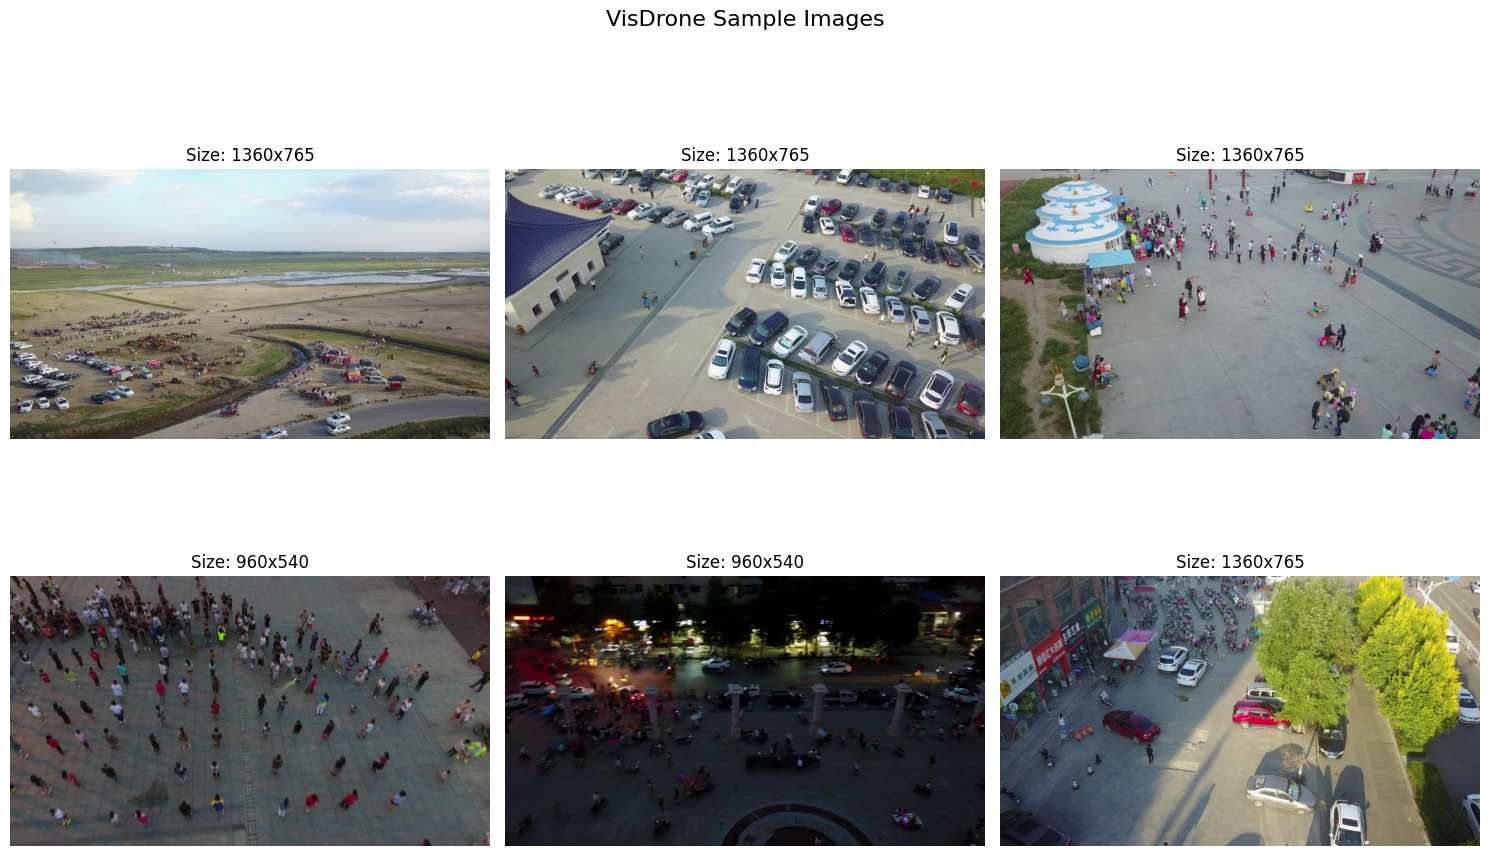

Saved: sample_images.png


In [29]:
import cv2
import matplotlib.pyplot as plt
import glob
import random

images = sorted(glob.glob('/content/visdrone/**/*.jpg', recursive=True))

# Select a range
selected_range = images[10:50]

# Randomly pick 6 images from that range
random.seed(42)
random_images = random.sample(selected_range, 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, img_path in enumerate(random_images):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img)
    axes[i].set_title(f"Size: {img.shape[1]}x{img.shape[0]}")
    axes[i].axis('off')

plt.suptitle("VisDrone Sample Images", fontsize=16)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()

print("Saved: sample_images.png")

Visualize with annotations

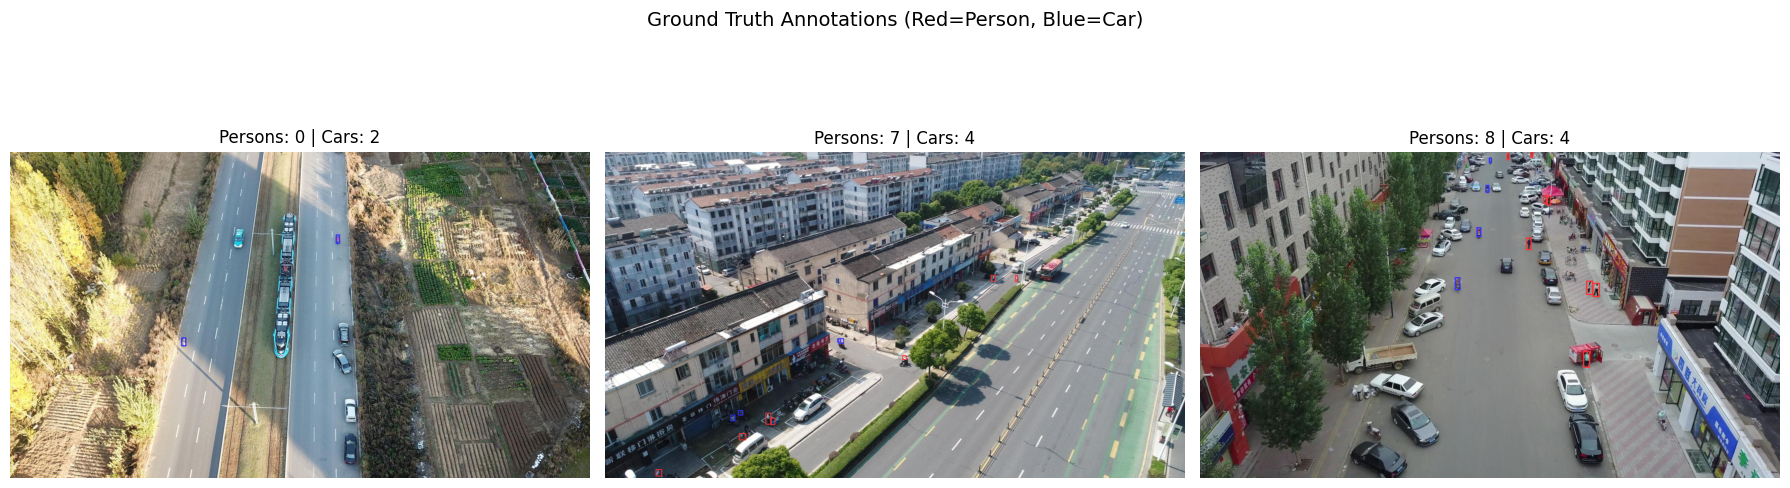

Saved: annotated_samples.png 


In [30]:
import os, cv2, glob
import matplotlib.pyplot as plt

def draw_annotations_yolo(img_path, ann_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()
    H, W = img.shape[:2]
    persons, cars = 0, 0

    with open(ann_path) as f:
        for line in f:
            p = line.strip().split()
            if len(p) < 5: continue
            cls = int(p[0])
            cx, cy, w, h = float(p[1]), float(p[2]), float(p[3]), float(p[4])

            # Convert normalized to pixel coords
            x1 = int((cx - w/2) * W)
            y1 = int((cy - h/2) * H)
            x2 = int((cx + w/2) * W)
            y2 = int((cy + h/2) * H)

            if cls == 0:  # person
                color = (255, 50, 50)
                persons += 1
            elif cls == 1:  # car
                color = (50, 50, 255)
                cars += 1
            else:
                continue

            cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)

    return img, persons, cars

train_annots = glob.glob('/content/visdrone/VisDrone_Dataset/VisDrone2019-DET-train/labels/*.txt')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
count = 0

for ann_path in train_annots:
    img_path = ann_path.replace('/labels/', '/images/').replace('.txt', '.jpg')
    if not os.path.exists(img_path): continue
    img, p, c = draw_annotations_yolo(img_path, ann_path)
    if p > 0 or c > 0:
        axes[count].imshow(img)
        axes[count].set_title(f'Persons: {p} | Cars: {c}')
        axes[count].axis('off')
        count += 1
        if count == 3: break

plt.suptitle("Ground Truth Annotations (Red=Person, Blue=Car)", fontsize=14)
plt.tight_layout()
plt.savefig('annotated_samples.png', dpi=150)
plt.show()
print("Saved: annotated_samples.png ")

PyTorch Dataset Class

In [31]:
import os, cv2, glob, torch, torchvision
from torch.utils.data import Dataset, DataLoader
import random

class VisDroneDataset(Dataset):
    def __init__(self, img_dir, ann_dir):
        self.samples = []
        img_files = glob.glob(os.path.join(img_dir, '*.jpg'))
        for img_path in img_files:
            ann_path = os.path.join(ann_dir, os.path.basename(img_path).replace('.jpg', '.txt'))
            if os.path.exists(ann_path):
                self.samples.append((img_path, ann_path))
        print(f"Dataset loaded: {len(self.samples)} samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, ann_path = self.samples[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]

        boxes, labels = [], []
        with open(ann_path) as f:
            for line in f:
                p = line.strip().split()
                if len(p) < 5: continue
                cls = int(p[0])
                cx, cy, w, h = float(p[1]), float(p[2]), float(p[3]), float(p[4])

                x1 = (cx - w/2) * W
                y1 = (cy - h/2) * H
                x2 = (cx + w/2) * W
                y2 = (cy + h/2) * H

                x1 = max(0, x1)
                y1 = max(0, y1)
                x2 = min(W, x2)
                y2 = min(H, y2)

                if x2 <= x1 or y2 <= y1: continue
                if cls not in [0, 1]: continue

                boxes.append([x1, y1, x2, y2])
                labels.append(cls + 1)  # 1=person, 2=car (0 is background)

        if len(boxes) == 0:
            boxes  = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros(0, dtype=torch.int64)
        else:
            boxes  = torch.tensor(boxes,  dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([idx])
        }

        img_tensor = torchvision.transforms.functional.to_tensor(img)
        return img_tensor, target

def collate_fn(batch):
    return tuple(zip(*batch))

print("Dataset class defined")

Dataset class defined


Train and Validation

In [32]:
TRAIN_IMG = '/content/visdrone/VisDrone_Dataset/VisDrone2019-DET-train/images'
TRAIN_ANN = '/content/visdrone/VisDrone_Dataset/VisDrone2019-DET-train/labels'
VAL_IMG   = '/content/visdrone/VisDrone_Dataset/VisDrone2019-DET-val/images'
VAL_ANN   = '/content/visdrone/VisDrone_Dataset/VisDrone2019-DET-val/labels'

train_dataset = VisDroneDataset(TRAIN_IMG, TRAIN_ANN)
val_dataset   = VisDroneDataset(VAL_IMG,   VAL_ANN)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,
                          collate_fn=collate_fn, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=2, shuffle=False,
                          collate_fn=collate_fn, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

Dataset loaded: 6471 samples
Dataset loaded: 548 samples
Train batches: 1618
Val batches:   274


Model Load

In [33]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_model(num_classes):
    model = fasterrcnn_resnet50_fpn(pretrained=True)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

model = get_model(num_classes=3)
model.to(device)
print("Model loaded")

Using device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 130MB/s]


Model loaded


Train

In [34]:
from torch.optim import SGD
from torch.optim.lr_scheduler import StepLR
from tqdm import tqdm

optimizer = SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
scheduler = StepLR(optimizer, step_size=3, gamma=0.5)

NUM_EPOCHS = 20
train_losses = []

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0
    batch_count = 0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{NUM_EPOCHS}]")

    for images, targets in loop:
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k,v in t.items()} for t in targets]

        if any(len(t['boxes']) == 0 for t in targets):
            continue

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()
        batch_count += 1
        loop.set_postfix(loss=f"{losses.item():.4f}")

    scheduler.step()
    avg_loss = epoch_loss / max(batch_count, 1)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Avg Loss: {avg_loss:.4f}")

print("\nTraining complete")
torch.save(model.state_dict(), '/content/faster_rcnn_drone.pth')
print("Model saved ")

Epoch [1/20]: 100%|██████████| 1618/1618 [21:32<00:00,  1.25it/s, loss=0.6763]


Epoch [1/20] Avg Loss: 0.8672


Epoch [2/20]: 100%|██████████| 1618/1618 [21:48<00:00,  1.24it/s, loss=0.4948]


Epoch [2/20] Avg Loss: 0.7767


Epoch [3/20]: 100%|██████████| 1618/1618 [21:50<00:00,  1.23it/s, loss=0.8396]


...

Epoch [9/20] Avg Loss: 0.6081


Epoch [10/20]: 100%|██████████| 1618/1618 [22:08<00:00,  1.22it/s, loss=0.3813]


Epoch [10/20] Avg Loss: 0.5949


Epoch [11/20]:  55%|█████▌    | 896/1618 [12:13<09:51,  1.22it/s, loss=0.6724]


KeyboardInterrupt: 

In [36]:
torch.save(model.state_dict(), '/content/faster_rcnn_drone.pth')
print("Model saved at current epoch")

Model saved at current epoch


Training Loss plot

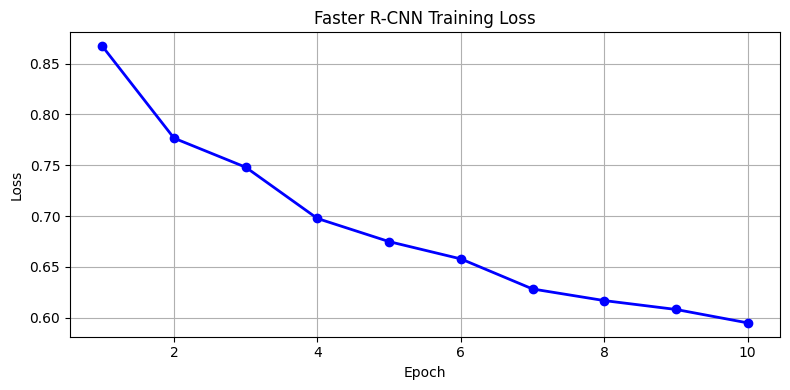

Saved: training_loss.png


In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_losses)+1), train_losses, 'b-o', linewidth=2, markersize=6)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Faster R-CNN Training Loss')
plt.grid(True)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150)
plt.show()
print("Saved: training_loss.png")

Detection Function

In [39]:
def detect_and_count(img_path, model, device, threshold=0.3):
    model.eval()

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_tensor = torchvision.transforms.functional.to_tensor(img_rgb).unsqueeze(0).to(device)

    with torch.no_grad():
        predictions = model(img_tensor)[0]

    result = img_rgb.copy()
    person_count = 0
    car_count = 0

    for box, label, score in zip(predictions['boxes'], predictions['labels'], predictions['scores']):
        if score < threshold:
            continue

        x1, y1, x2, y2 = map(int, box.tolist())
        label = label.item()

        if label == 1:
            person_count += 1
            color = (255, 50, 50)
            text = f'Person {score:.2f}'
        elif label == 2:
            car_count += 1
            color = (50, 50, 255)
            text = f'Car {score:.2f}'
        else:
            continue

        cv2.rectangle(result, (x1,y1), (x2,y2), color, 2)
        cv2.putText(result, text, (x1, max(y1-5, 0)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

    # Counter overlay
    overlay = result.copy()
    cv2.rectangle(overlay, (0,0), (280, 65), (0,0,0), -1)
    cv2.addWeighted(overlay, 0.5, result, 0.5, 0, result)
    cv2.putText(result, f'Humans: {person_count}', (8, 25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,100,100), 2)
    cv2.putText(result, f'Cars:   {car_count}', (8, 55),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (100,100,255), 2)

    return result, person_count, car_count

print("Detection function ready")

Detection function ready


Detection result

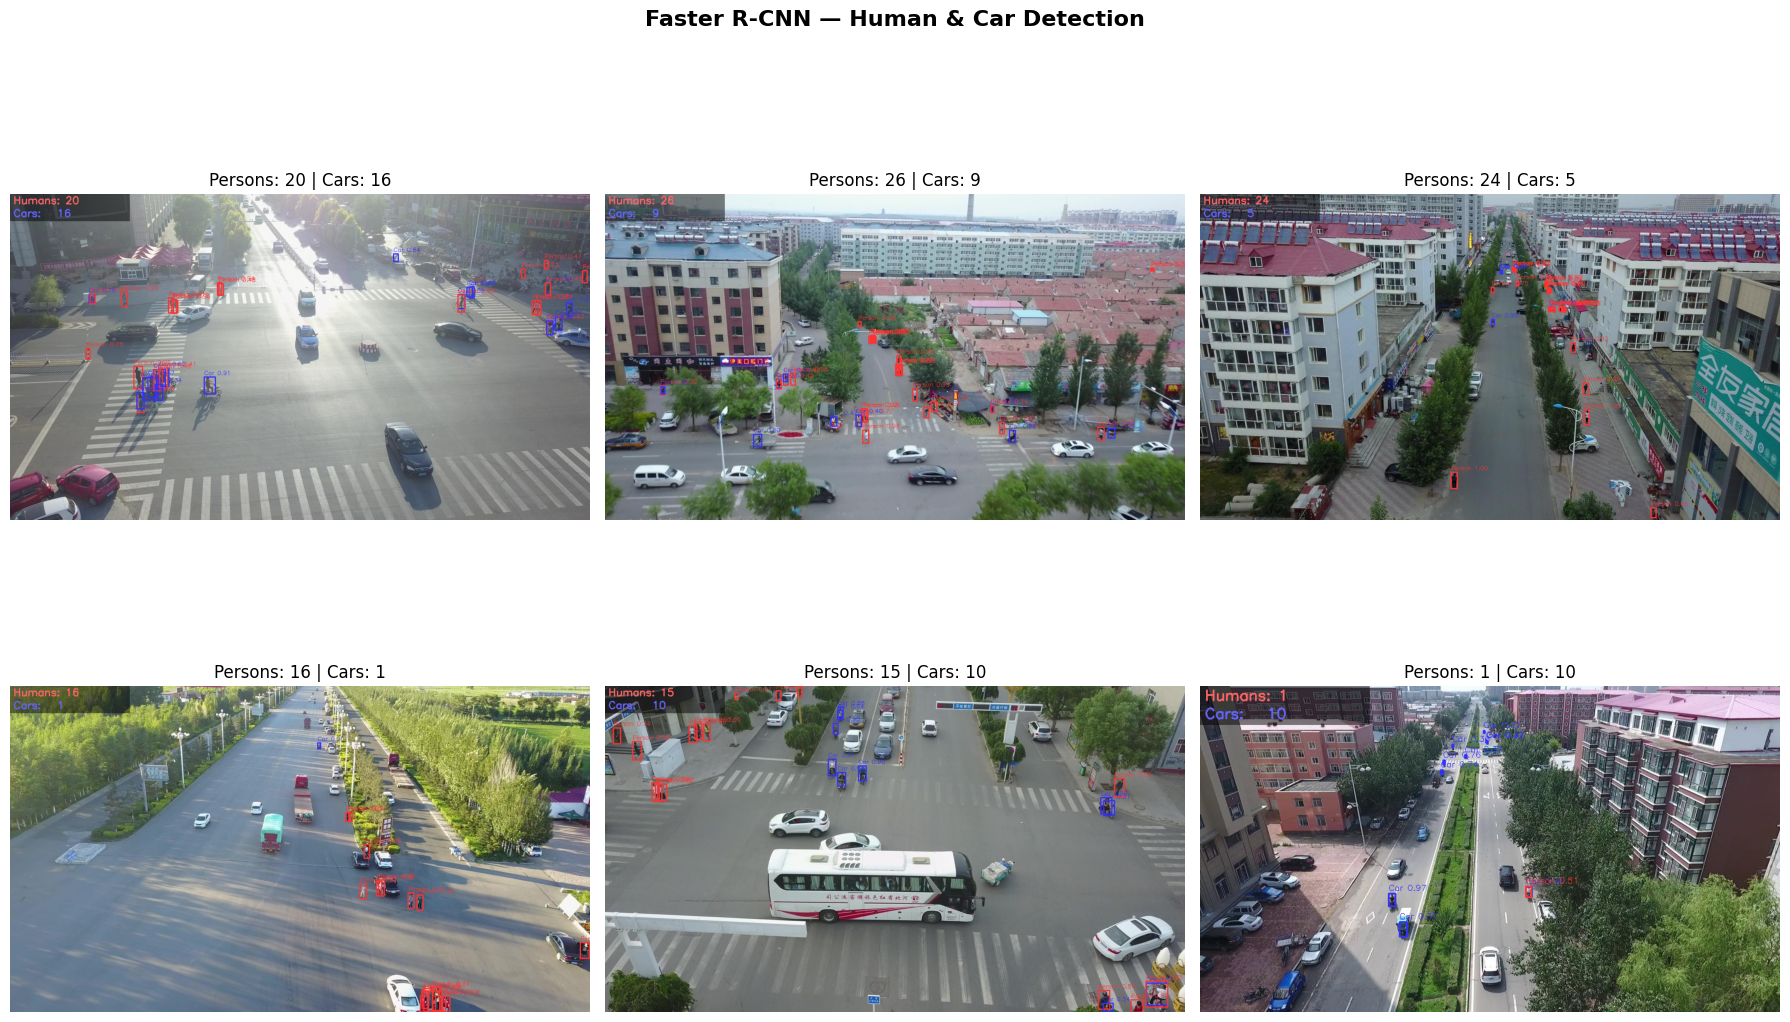

Saved: detection_results.png


In [40]:
import glob

val_imgs_list = glob.glob(VAL_IMG + '/*.jpg')[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, img_path in enumerate(val_imgs_list):
    result, p, c = detect_and_count(img_path, model, device)
    axes[i].imshow(result)
    axes[i].set_title(f'Persons: {p} | Cars: {c}', fontsize=12)
    axes[i].axis('off')

plt.suptitle('Faster R-CNN — Human & Car Detection', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('detection_results.png', dpi=150)
plt.show()
print("Saved: detection_results.png")

Counting

Running detection: 100%|██████████| 20/20 [00:02<00:00,  6.86it/s]


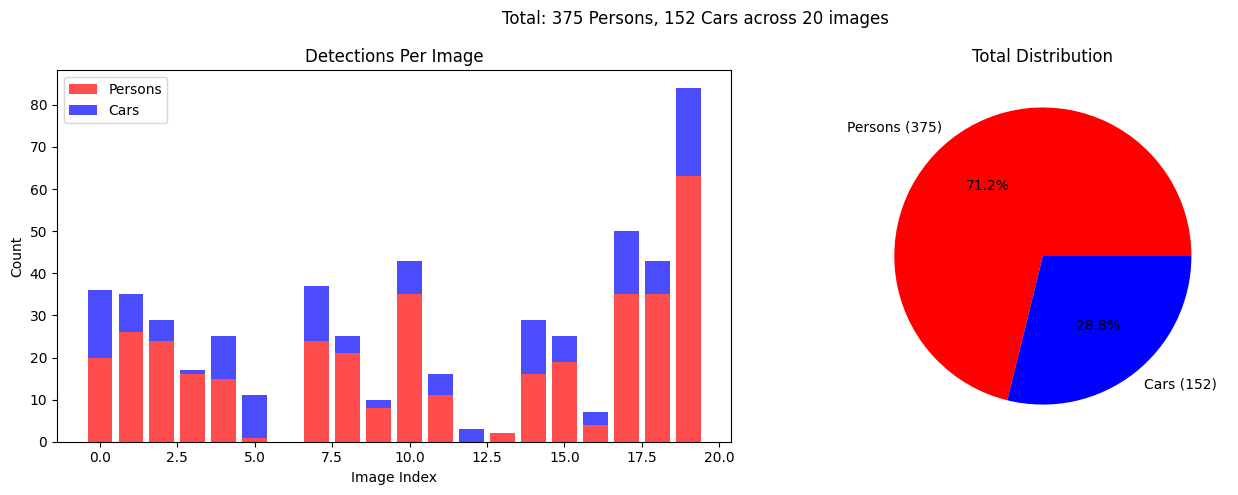

Saved: counting_stats.png ✓


In [41]:
from tqdm import tqdm

val_imgs_list = glob.glob(VAL_IMG + '/*.jpg')[:20]
all_persons, all_cars = [], []

for img_path in tqdm(val_imgs_list, desc="Running detection"):
    _, p, c = detect_and_count(img_path, model, device)
    all_persons.append(p)
    all_cars.append(c)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(all_persons)), all_persons, color='red',  alpha=0.7, label='Persons')
axes[0].bar(range(len(all_cars)),    all_cars,    color='blue', alpha=0.7, label='Cars', bottom=all_persons)
axes[0].set_xlabel('Image Index')
axes[0].set_ylabel('Count')
axes[0].set_title('Detections Per Image')
axes[0].legend()

axes[1].pie(
    [max(sum(all_persons), 1), max(sum(all_cars), 1)],
    labels=[f'Persons ({sum(all_persons)})', f'Cars ({sum(all_cars)})'],
    colors=['red', 'blue'], autopct='%1.1f%%'
)
axes[1].set_title('Total Distribution')

plt.suptitle(f'Total: {sum(all_persons)} Persons, {sum(all_cars)} Cars across {len(val_imgs_list)} images')
plt.tight_layout()
plt.savefig('counting_stats.png', dpi=150)
plt.show()
print("Saved: counting_stats.png ✓")

Evaluation

In [42]:
from torchvision.ops import box_iou
from tqdm import tqdm

def evaluate_model(model, val_loader, device, threshold=0.3, iou_threshold=0.5):
    model.eval()

    all_tp_person, all_fp_person, all_fn_person = 0, 0, 0
    all_tp_car,    all_fp_car,    all_fn_car    = 0, 0, 0

    with torch.no_grad():
        for images, targets in tqdm(val_loader, desc="Evaluating"):
            images  = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k,v in t.items()} for t in targets]
            predictions = model(images)

            for pred, target in zip(predictions, targets):
                for cls_id in [1, 2]:
                    pred_mask  = (pred['labels'] == cls_id) & (pred['scores'] >= threshold)
                    pred_boxes = pred['boxes'][pred_mask]
                    gt_mask    = target['labels'] == cls_id
                    gt_boxes   = target['boxes'][gt_mask]

                    tp = fp = fn = 0
                    if len(pred_boxes) == 0:
                        fn = len(gt_boxes)
                    elif len(gt_boxes) == 0:
                        fp = len(pred_boxes)
                    else:
                        iou_matrix = box_iou(pred_boxes, gt_boxes)
                        matched_gt = set()
                        for i in range(len(pred_boxes)):
                            best_iou, best_j = iou_matrix[i].max(0)
                            if best_iou >= iou_threshold and best_j.item() not in matched_gt:
                                tp += 1
                                matched_gt.add(best_j.item())
                            else:
                                fp += 1
                        fn = len(gt_boxes) - tp

                    if cls_id == 1:
                        all_tp_person += tp
                        all_fp_person += fp
                        all_fn_person += fn
                    else:
                        all_tp_car += tp
                        all_fp_car += fp
                        all_fn_car += fn

    def calc(tp, fp, fn):
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1        = 2*precision*recall / (precision+recall) if (precision+recall) > 0 else 0
        return precision, recall, f1

    p_p, r_p, f1_p = calc(all_tp_person, all_fp_person, all_fn_person)
    p_c, r_c, f1_c = calc(all_tp_car,    all_fp_car,    all_fn_car)

    print("EVALUATION RESULTS")
    print(f"Person  — Precision: {p_p:.3f} | Recall: {r_p:.3f} | F1: {f1_p:.3f}")
    print(f"Car     — Precision: {p_c:.3f} | Recall: {r_c:.3f} | F1: {f1_c:.3f}")
    print(f"Overall — Precision: {(p_p+p_c)/2:.3f} | Recall: {(r_p+r_c)/2:.3f} | F1: {(f1_p+f1_c)/2:.3f}")

evaluate_model(model, val_loader, device)

Evaluating: 100%|██████████| 274/274 [01:18<00:00,  3.47it/s]

EVALUATION RESULTS
Person  — Precision: 0.423 | Recall: 0.627 | F1: 0.505
Car     — Precision: 0.410 | Recall: 0.529 | F1: 0.462
Overall — Precision: 0.417 | Recall: 0.578 | F1: 0.484


output save

In [43]:
import shutil, os
os.makedirs('/content/outputs', exist_ok=True)

for f in ['sample_images.png', 'annotated_samples.png', 'training_loss.png',
          'detection_results.png', 'counting_stats.png']:
    if os.path.exists(f):
        shutil.copy(f, '/content/outputs/')
        print(f"Copied: {f} ")

shutil.copy('/content/faster_rcnn_drone.pth', '/content/outputs/')
print("Copied: model weights")

!zip -r /content/outputs.zip /content/outputs/
from google.colab import files
files.download('/content/outputs.zip')
print("Download started")

Copied: sample_images.png 
Copied: annotated_samples.png 
Copied: training_loss.png 
Copied: detection_results.png 
Copied: counting_stats.png 
Copied: model weights
  adding: content/outputs/ (stored 0%)
  adding: content/outputs/detection_results.png (deflated 0%)
  adding: content/outputs/annotated_samples.png (deflated 0%)
  adding: content/outputs/sample_images.png (deflated 0%)
  adding: content/outputs/counting_stats.png (deflated 15%)
  adding: content/outputs/training_loss.png (deflated 12%)
  adding: content/outputs/faster_rcnn_drone.pth (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started
